In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from scipy.stats import kruskal

In [82]:
df = pd.read_csv('../Data/HRDataset_v14.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [83]:
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')
df['Attrition'] = df['DateofTermination'].notna().astype(int) # 1 if terminated, 0 if still employed

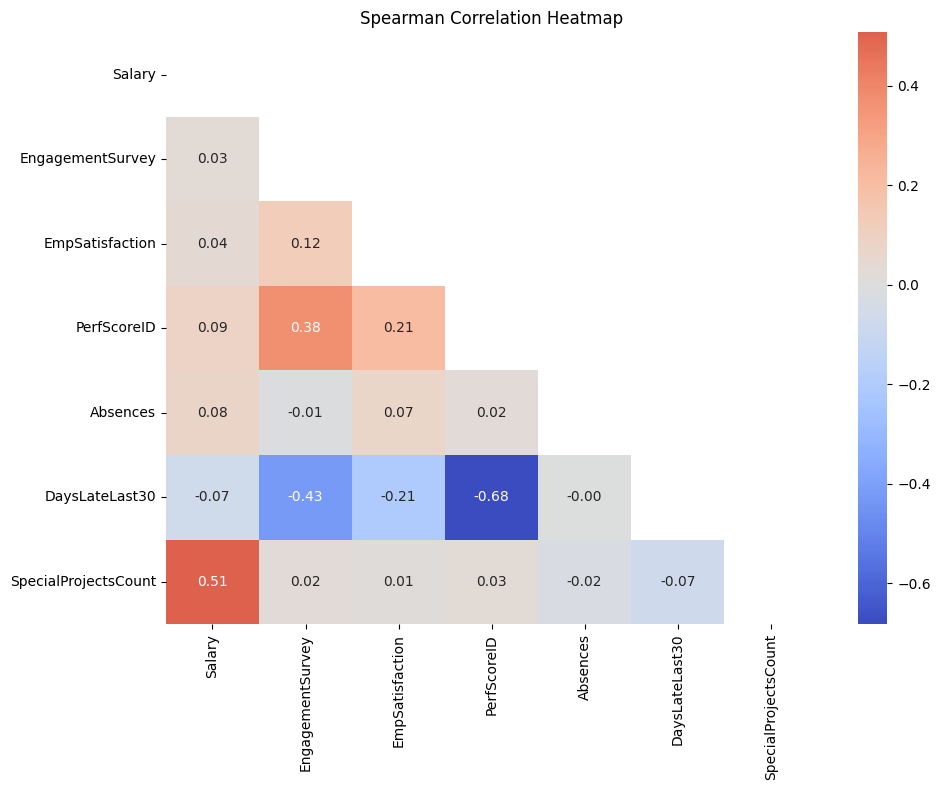

In [84]:
numeric_cols = ['Salary','EngagementSurvey','EmpSatisfaction','PerfScoreID',
                'Absences','DaysLateLast30','SpecialProjectsCount']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, mask=np.triu(np.ones((len(numeric_cols),len(numeric_cols)),dtype=bool)))
plt.title('Spearman Correlation Heatmap')
plt.tight_layout()

Attrition rate: 33.4%
Department
Production              0.397129
Software Engineering    0.363636
Admin Offices           0.222222
IT/IS                   0.200000
Sales                   0.161290
Executive Office        0.000000
Name: Attrition, dtype: float64


Text(0.5, 0, 'Attrition Rate')

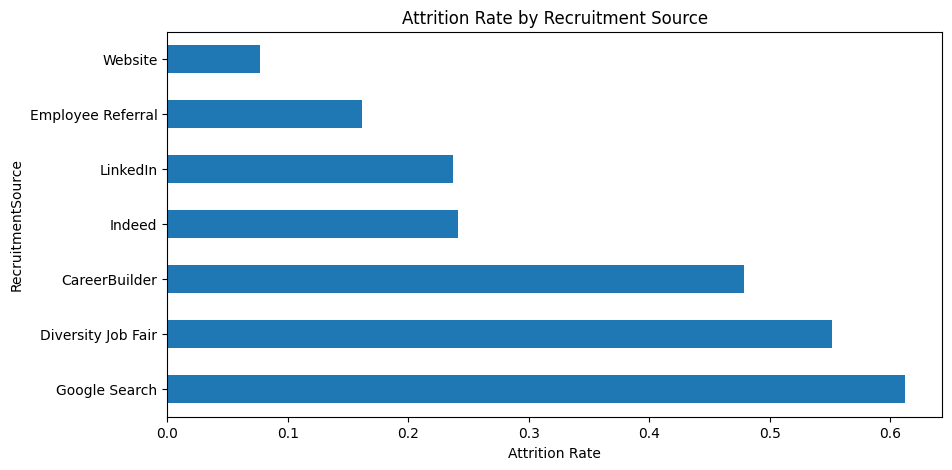

In [85]:
print(f"Attrition rate: {df['Attrition'].mean():.1%}")
print(df.groupby('Department')['Attrition'].mean().sort_values(ascending=False))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
df.groupby('RecruitmentSource')['Attrition'].agg(['mean','count']).query('count >= 5') \
  .sort_values('mean', ascending=False)['mean'].plot(kind='barh', ax=ax)
ax.set_title('Attrition Rate by Recruitment Source')
ax.set_xlabel('Attrition Rate')

# Salaries and engagement

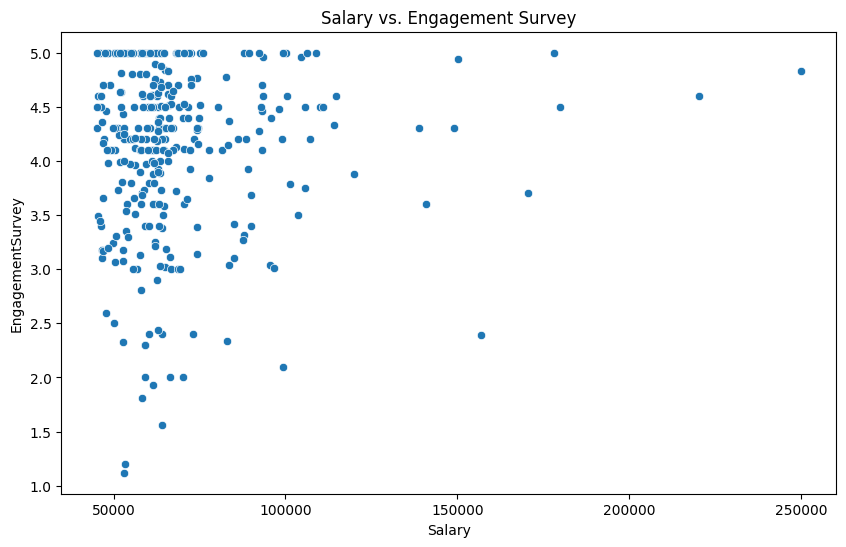

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Salary', y='EngagementSurvey')
plt.title('Salary vs. Engagement Survey')
plt.show()

In [87]:
def get_spearman(group, col1, col2):
    n_count = len(group)
    
    if n_count < 5:
        return pd.Series({'rho': np.nan, 'p_value': np.nan, 'n': n_count})
    
    if group[col1].nunique() <= 1 or group[group[col2].notna()][col2].nunique() <= 1:
        return pd.Series({'rho': np.nan, 'p_value': np.nan, 'n': n_count})
    
    rho, p = spearmanr(group[col1], group[col2])
    return pd.Series({'rho': rho, 'p_value': p, 'n': n_count})

dept_corr = df.groupby('Department').apply(
    get_spearman, 
    col1='Salary', 
    col2='EngagementSurvey'
).reset_index()

mask = dept_corr['p_value'].notna()
dept_corr.loc[mask, 'p_corrected'] = multipletests(
    dept_corr.loc[mask, 'p_value'], method='holm')[1]

print(dept_corr)

             Department       rho   p_value      n  p_corrected
0         Admin Offices  0.565752  0.112342    9.0     0.561708
1      Executive Office       NaN       NaN    1.0          NaN
2                 IT/IS  0.042366  0.770190   50.0     1.000000
3     Production        -0.019188  0.782731  209.0     1.000000
4                 Sales  0.288459  0.115549   31.0     0.561708
5  Software Engineering  0.273349  0.416037   11.0     1.000000


In [88]:
stats_df = df.groupby('Department').apply(
    get_spearman, 
    col1='Salary', 
    col2='PerfScoreID'
).reset_index()


mask = stats_df['p_value'].notna()
stats_df.loc[mask, 'p_corrected'] = multipletests(
    stats_df.loc[mask, 'p_value'], method='holm')[1]
stats_df['is_significant'] = stats_df['p_corrected'] < 0.05
print(stats_df.sort_values('rho', ascending=False))

             Department       rho   p_value      n  p_corrected  \
4                 Sales  0.275622  0.133412   31.0     0.533649   
2                 IT/IS  0.166684  0.247298   50.0     0.741894   
5  Software Engineering  0.121854  0.721158   11.0     1.000000   
3     Production         0.046223  0.506313  209.0     1.000000   
0         Admin Offices       NaN       NaN    9.0          NaN   
1      Executive Office       NaN       NaN    1.0          NaN   

   is_significant  
4           False  
2           False  
5           False  
3           False  
0           False  
1           False  


# Performance

In [89]:
df['PerfScoreID'].unique()

array([4, 3, 2, 1])

In [90]:
stats_df = df.groupby('Department').apply(
    get_spearman, 
    col1='EngagementSurvey', 
    col2='PerfScoreID'
).reset_index()


mask = stats_df['p_value'].notna()
stats_df.loc[mask, 'p_corrected'] = multipletests(
    stats_df.loc[mask, 'p_value'], method='holm')[1]
stats_df['is_significant'] = stats_df['p_corrected'] < 0.05
print(stats_df.sort_values('rho', ascending=False))

             Department       rho       p_value      n   p_corrected  \
5  Software Engineering  0.639740  3.402535e-02   11.0  4.431770e-02   
4                 Sales  0.535827  1.891998e-03   31.0  5.675994e-03   
3     Production         0.361299  7.676287e-08  209.0  3.070515e-07   
2                 IT/IS  0.322966  2.215885e-02   50.0  4.431770e-02   
0         Admin Offices       NaN           NaN    9.0           NaN   
1      Executive Office       NaN           NaN    1.0           NaN   

   is_significant  
5            True  
4            True  
3            True  
2            True  
0           False  
1           False  


In [91]:
stats_df = df.groupby('Department').apply(
    get_spearman, 
    col1='EmpSatisfaction', 
    col2='PerfScoreID'
).reset_index()


mask = stats_df['p_value'].notna()
stats_df.loc[mask, 'p_corrected'] = multipletests(
    stats_df.loc[mask, 'p_value'], method='holm')[1]
stats_df['is_significant'] = stats_df['p_corrected'] < 0.05
print(stats_df.sort_values('rho', ascending=False))

             Department       rho   p_value      n  p_corrected  \
2                 IT/IS  0.371036  0.007985   50.0     0.031941   
4                 Sales  0.368039  0.041642   31.0     0.083284   
5  Software Engineering  0.206593  0.542203   11.0     0.542203   
3     Production         0.166796  0.015787  209.0     0.047360   
0         Admin Offices       NaN       NaN    9.0          NaN   
1      Executive Office       NaN       NaN    1.0          NaN   

   is_significant  
2            True  
4           False  
5           False  
3            True  
0           False  
1           False  


# Salaries

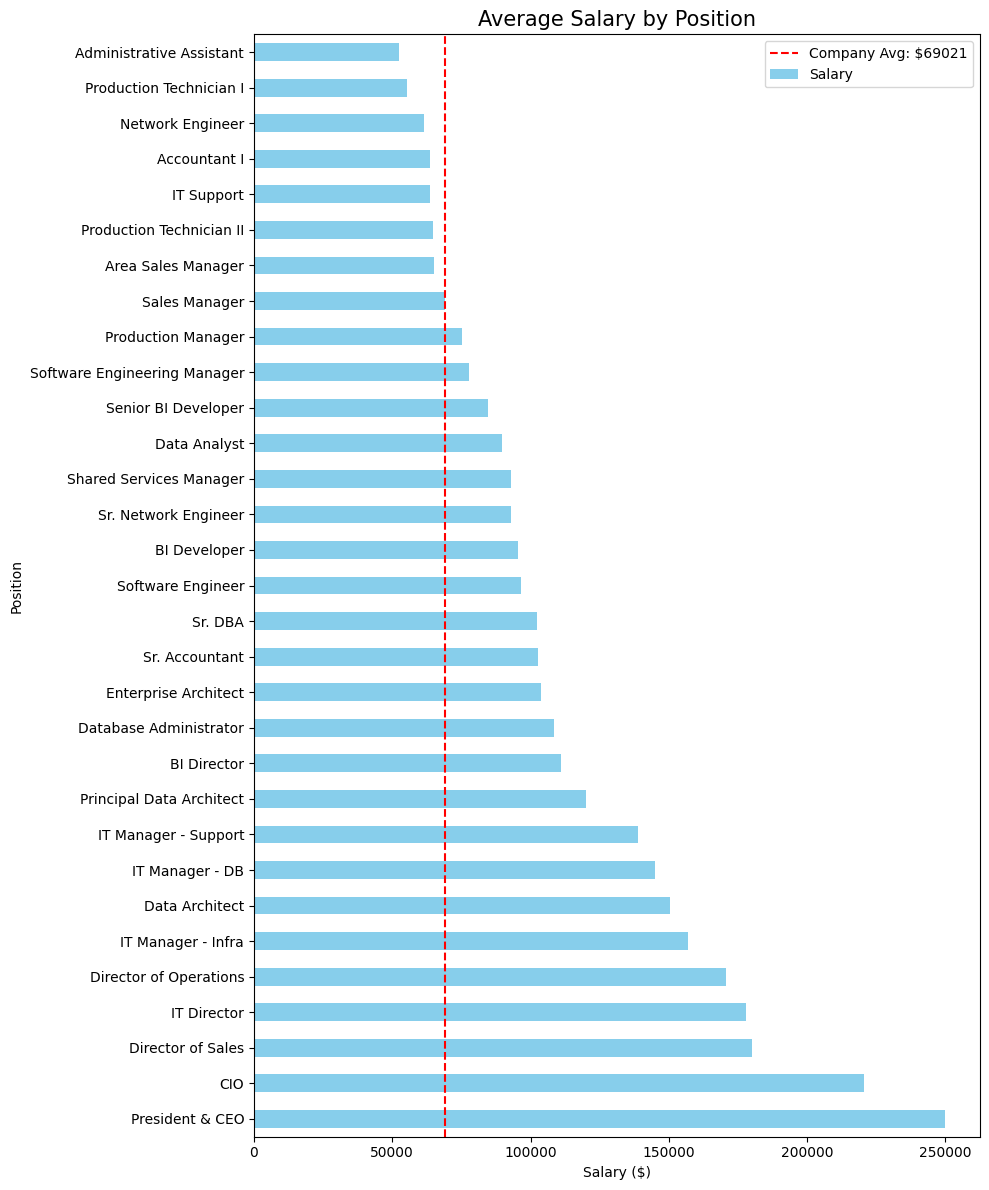

In [92]:
df['Position'] = df['Position'].str.strip()
salary_by_pos_mean = df.groupby('Position')['Salary'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 12))
salary_by_pos_mean.plot(kind='barh', color='skyblue')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Position', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

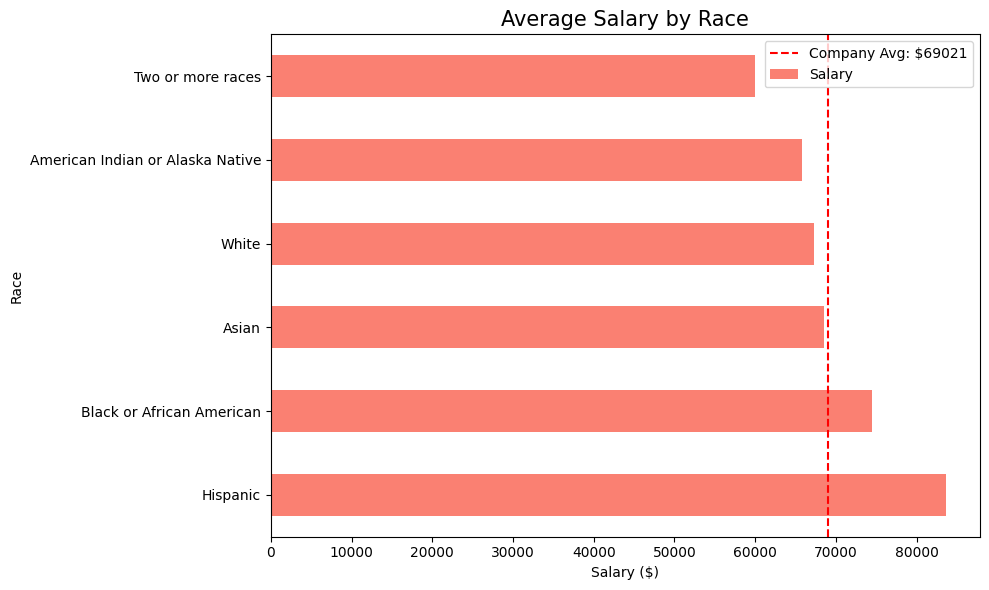

In [93]:
salary_by_race = df.groupby('RaceDesc')['Salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
salary_by_race.plot(kind='barh', color='salmon')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--',
            label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Race', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Race')
plt.legend()
plt.tight_layout()
plt.show()

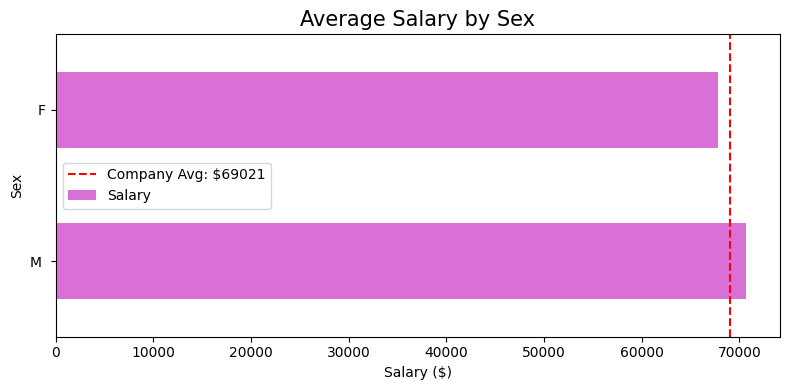

In [94]:
salary_by_sex = df.groupby('Sex')['Salary'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
salary_by_sex.plot(kind='barh', color='orchid')
plt.axvline(df['Salary'].mean(), color='red', linestyle='--', label=f"Company Avg: ${df['Salary'].mean():.0f}")
plt.title('Average Salary by Sex', fontsize=15)
plt.xlabel('Salary ($)')
plt.ylabel('Sex')
plt.legend()
plt.tight_layout()
plt.show()

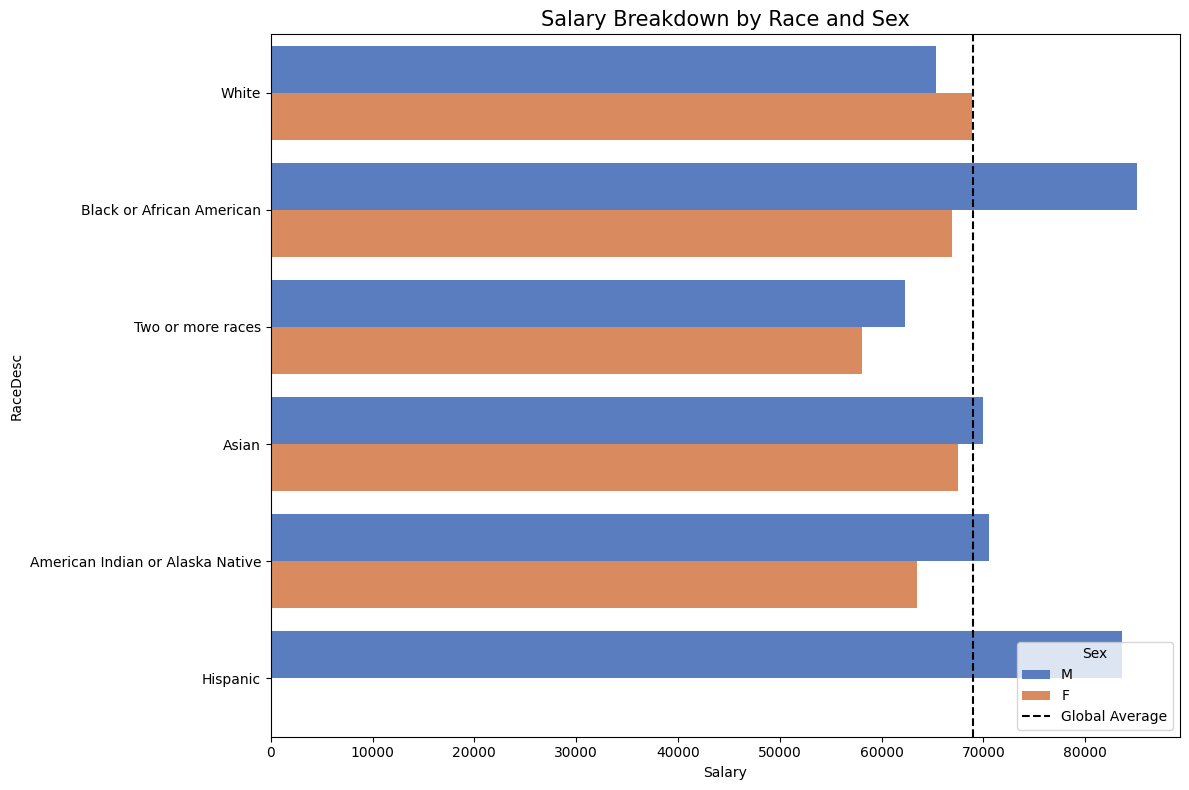

In [95]:
plt.figure(figsize=(12, 8))
sns.barplot(data=df, x='Salary', y='RaceDesc', hue='Sex', estimator=np.mean, errorbar=None, palette='muted')

plt.axvline(df['Salary'].mean(), color='black', linestyle='--', label='Global Average')
plt.title('Salary Breakdown by Race and Sex', fontsize=15)
plt.legend(title='Sex', loc='lower right')
plt.tight_layout()
plt.show()

In [96]:
combined_summary = df.groupby(['RaceDesc', 'Sex'])['Salary'].agg(['count', 'mean', 'median'])
combined_summary = combined_summary.sort_values(['RaceDesc', 'mean'], ascending=[True, False]).round(2)
print("\nDetailed Salary Summary (Race & Sex):")
print(combined_summary)


Detailed Salary Summary (Race & Sex):
                                      count      mean   median
RaceDesc                         Sex                          
American Indian or Alaska Native M        1  70545.00  70545.0
                                 F        2  63436.50  63436.5
Asian                            M       12  69939.42  64731.0
                                 F       17  67520.12  63676.0
Black or African American        M       33  85066.12  71339.0
                                 F       47  66963.83  61584.0
Hispanic                         M        1  83667.00  83667.0
Two or more races                M        5  62313.80  61568.0
                                 F        6  58068.50  57837.0
White                            F      104  68846.52  62405.0
                                 M       83  65334.13  61809.0


# Statistical testing for discrimination

## Races and sex

In [97]:
def cles(lesser, greater):
    if len(lesser) == 0 or len(greater) == 0:
        return np.nan
    diffs = [x < y for x in lesser for y in greater]
    return sum(diffs) / (len(lesser) * len(greater))

def salaries_stat_testing(group_a, group_b, label):
    # 1. Check for sufficient sample size
    if len(group_a) < 3 or len(group_b) < 3:
        return {
            "Comparison": label, "Method": "Insufficient Data", 
            "P-Value": np.nan, "Effect Size": np.nan, "Effect Name": "N/A"
        }

    # Shapiro-Wilk test for normality
    _, p_norm_a = stats.shapiro(group_a)
    _, p_norm_b = stats.shapiro(group_b)

    # T-Test vs. Mann-Whitney U
    if p_norm_a > 0.05 and p_norm_b > 0.05:
        _, p_val = stats.ttest_ind(group_a, group_b, nan_policy='omit')
        method = "T-test"
        # Cohen's d for T-tests
        effect_size = (group_a.mean() - group_b.mean()) / np.sqrt(((group_a.std()**2) + (group_b.std()**2)) / 2)
        effect_name = "Cohen's d"
    else:
        _, p_val = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
        method = "Mann-Whitney U"
        # CLES for Mann-Whitney
        effect_size = cles(group_a, group_b)
        effect_name = "CLES"

    return {
        "Comparison": label, "Method": method, "P-Value": p_val,
        "Effect Size": round(effect_size, 4) if not np.isnan(effect_size) else np.nan,
        "Effect Name": effect_name
    }

def get_regression_summary(model, term_filter='Sex'):
    for k, v in model.params.items():
        if term_filter in k:
            p = model.pvalues[k]
            print(f"  {k}: coef = ${v:,.0f}, p = {p:.4f}")

df['Sex'] = df['Sex'].str.strip()
df['RaceDesc'] = df['RaceDesc'].str.strip()

comparisons = [
    (df[df['RaceDesc'] == 'White']['Salary'], 
     df[df['RaceDesc'] == 'Black or African American']['Salary'], "White vs Black"),
    
    (df[(df['RaceDesc'] == 'White') & (df['Sex'] == 'M')]['Salary'],
     df[(df['RaceDesc'] == 'White') & (df['Sex'] == 'F')]['Salary'], "M vs F (White)"),
    
    (df[(df['RaceDesc'] == 'Black or African American') & (df['Sex'] == 'M')]['Salary'],
     df[(df['RaceDesc'] == 'Black or African American') & (df['Sex'] == 'F')]['Salary'], "M vs F (Black)")
]

results_df = pd.DataFrame([salaries_stat_testing(a, b, L) for a, b, L in comparisons])

mask = results_df['P-Value'].notna()
if mask.any():
    reject, corrected, _, _ = multipletests(results_df.loc[mask, 'P-Value'], method='holm')
    results_df.loc[mask, 'P-Corrected'] = corrected
    results_df.loc[mask, 'Significant'] = reject

print(results_df)

print("\n" + "="*60 + "\nREGRESSION: SEX EFFECT (CONTROLLING FOR CONFOUNDERS)\n" + "="*60)

m_overall = smf.ols('Salary ~ C(Sex) + C(Department) + C(Position)', data=df).fit()
print("\n--- Overall (Controlling for Dept + Position) ---")
get_regression_summary(m_overall)

black_df = df[df['RaceDesc'] == 'Black or African American']
if len(black_df) > 20:
    m_black = smf.ols('Salary ~ C(Sex) + C(Position)', data=black_df).fit()
    print("\n--- Black Employees (Controlling for Position) ---")
    get_regression_summary(m_black)

       Comparison          Method   P-Value  Effect Size Effect Name  \
0  White vs Black  Mann-Whitney U  0.078794       0.5679        CLES   
1  M vs F (White)  Mann-Whitney U  0.588411       0.5231        CLES   
2  M vs F (Black)  Mann-Whitney U  0.022198       0.3488        CLES   

   P-Corrected Significant  
0     0.157588       False  
1     0.588411       False  
2     0.066595       False  

REGRESSION: SEX EFFECT (CONTROLLING FOR CONFOUNDERS)

--- Overall (Controlling for Dept + Position) ---
  C(Sex)[T.M]: coef = $-159, p = 0.8336

--- Black Employees (Controlling for Position) ---
  C(Sex)[T.M]: coef = $-84, p = 0.9593


In [98]:
target_pos = 'Production Technician I'
race_filter = 'Black or African American'

sub_df = df[(df['RaceDesc'] == race_filter) & (df['Position'] == target_pos)]

summary = sub_df.groupby('Sex')['Salary'].agg(['count', 'mean', 'median'])
print(f"Comparison for {target_pos} ({race_filter} only):")
print(summary)

Comparison for Production Technician I (Black or African American only):
     count      mean   median
Sex                          
F       20  56517.65  56243.0
M       10  52820.20  52953.0


## Marital status

In [99]:
df['MaritalStatusID'].unique()

array([0, 1, 2, 4, 3])

In [100]:
df['MaritalDesc'].unique()

<StringArray>
['Single', 'Married', 'Divorced', 'Widowed', 'Separated']
Length: 5, dtype: str

In [101]:
df['MarriedID'].unique()

array([0, 1])

                             sum_sq     df         F    PR(>F)
C(MaritalDesc)         1.380281e+09    4.0  0.539562  0.706785
C(Sex)                 5.764337e+08    1.0  0.901329  0.343187
C(MaritalDesc):C(Sex)  1.687092e+09    4.0  0.659497  0.620600
Residual               1.925007e+11  301.0       NaN       NaN


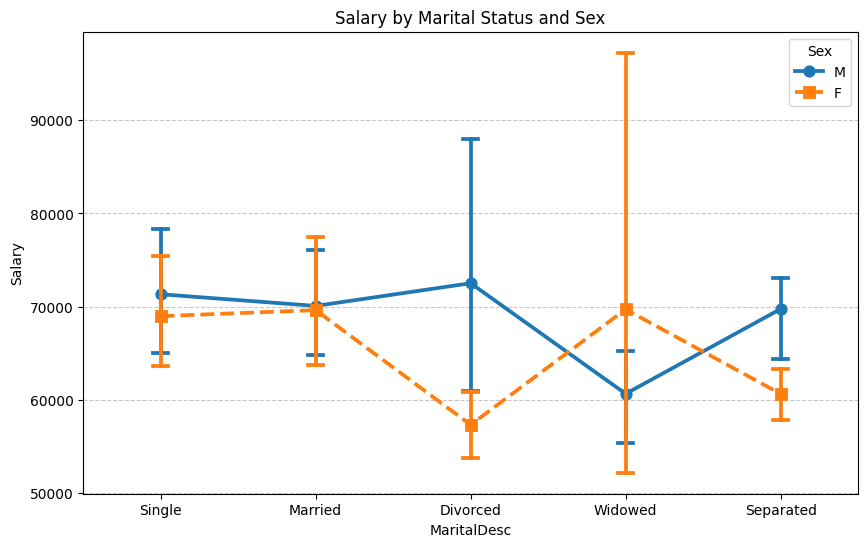

In [102]:
model = smf.ols('Salary ~ C(MaritalDesc) * C(Sex)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

plt.figure(figsize=(10, 6))
sns.pointplot(data=df, x='MaritalDesc', y='Salary', hue='Sex', 
              markers=["o", "s"], linestyles=["-", "--"], capsize=.1)
plt.title('Salary by Marital Status and Sex')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Managers and department

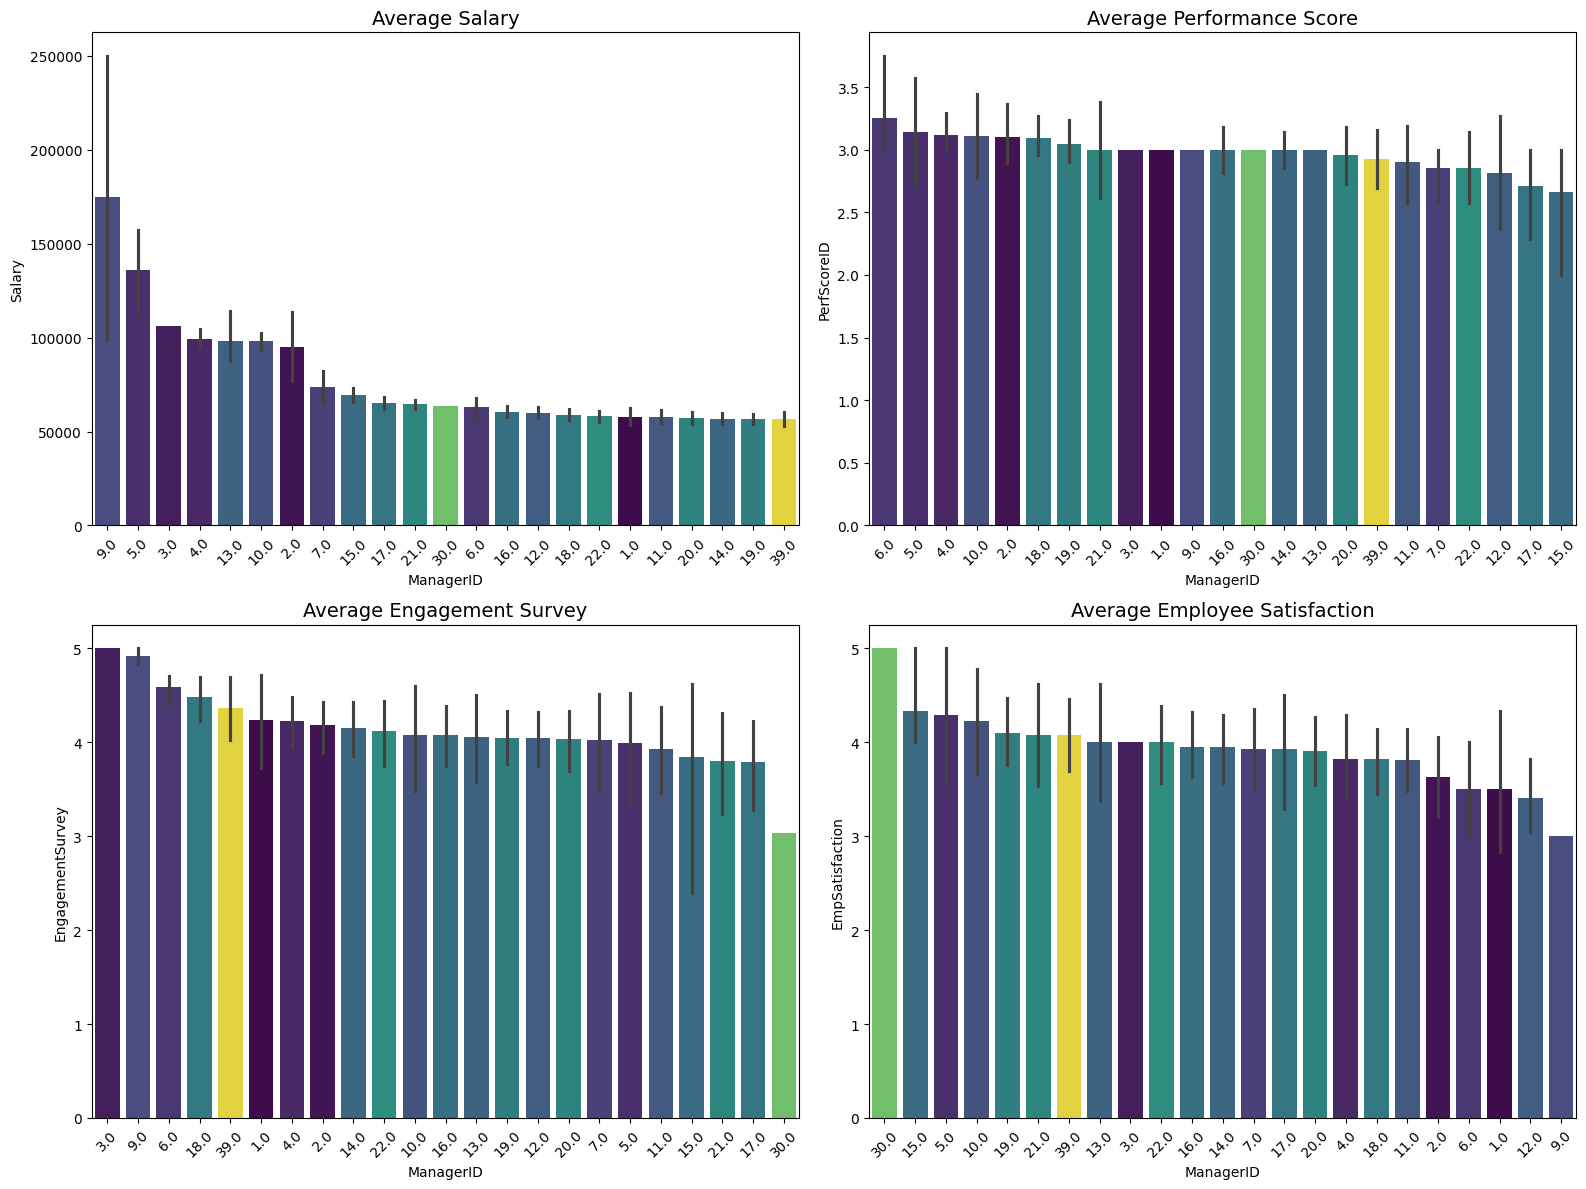

In [103]:
metrics = ['Salary', 'PerfScoreID', 'EngagementSurvey', 'EmpSatisfaction']
titles = ['Average Salary', 'Average Performance Score', 'Average Engagement Survey', 'Average Employee Satisfaction']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    order = df.groupby('ManagerID')[metric].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x='ManagerID', y=metric, order=order, palette='viridis', ax=axes[i], hue='ManagerID', legend=False)
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

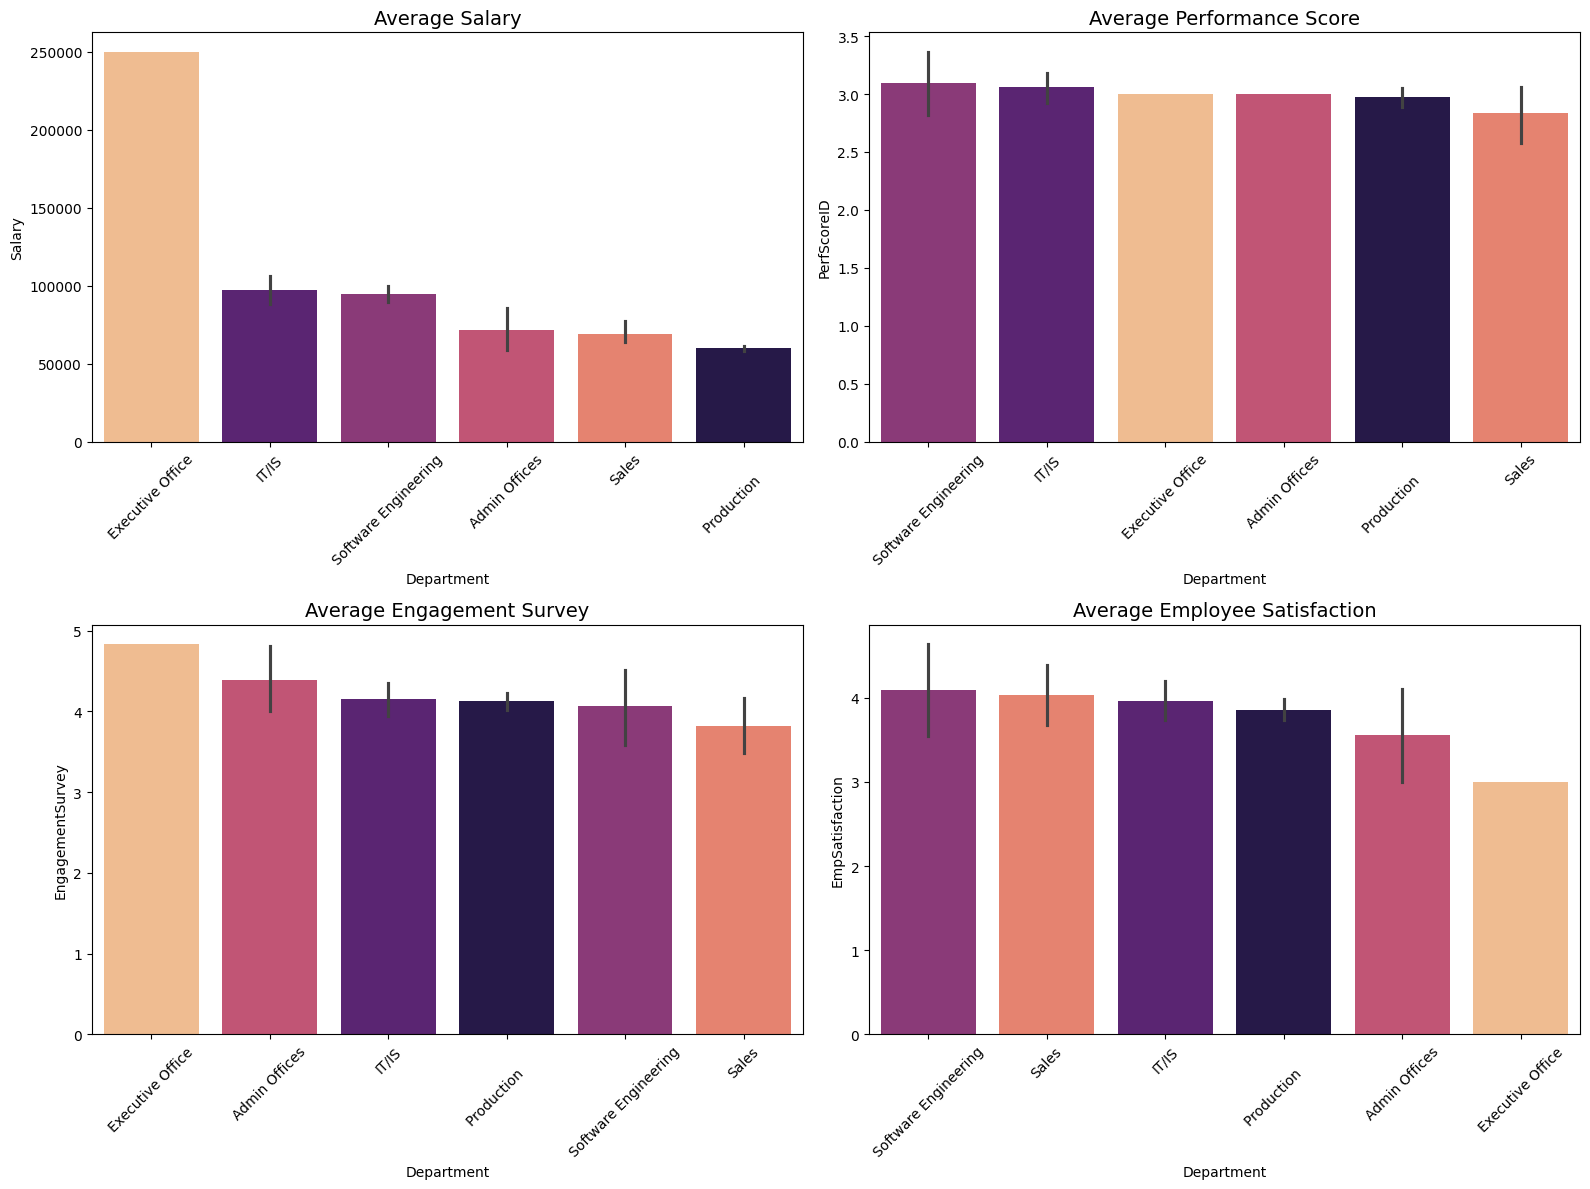

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    order = df.groupby('Department')[metric].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x='Department', y=metric, order=order, palette='magma', ax=axes[i], hue='Department', legend=False)
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()

In [105]:
metrics = ['PerfScoreID', 'EngagementSurvey', 'EmpSatisfaction']

categorical_metrics = ['PerfScoreID', 'EmpSatisfaction']  # discrete with few levels

for metric in categorical_metrics:
    ct = pd.crosstab(df['Department'], df[metric])
    chi2, p, dof, expected = chi2_contingency(ct)
    pct_low = (expected < 5).sum() / expected.size * 100
    print(f"Metric: {metric:<16} | Chi2 = {chi2:.2f} | P = {p:.4f} | "
          f"Cells with expected<5: {pct_low:.0f}%")
    if pct_low > 20:
        print(" >20% of cells have expected frequency < 5 — result unreliable")

# For EngagementSurvey (continuous), Kruskal-Wallis
groups = []

for _, g in df.groupby('Department'):
    cleaned_series = g['EngagementSurvey'].dropna()
    groups.append(cleaned_series)
h, p = kruskal(*groups)
print(f"\nEngagementSurvey across Departments: Kruskal-Wallis H={h:.2f}, p={p:.4f}")

Metric: PerfScoreID      | Chi2 = 10.35 | P = 0.7971 | Cells with expected<5: 62%
 >20% of cells have expected frequency < 5 — result unreliable
Metric: EmpSatisfaction  | Chi2 = 16.74 | P = 0.6697 | Cells with expected<5: 67%
 >20% of cells have expected frequency < 5 — result unreliable

EngagementSurvey across Departments: Kruskal-Wallis H=5.16, p=0.3965


In [106]:
for metric in categorical_metrics:
    ct = pd.crosstab(df['ManagerID'], df[metric])
    chi2, p, dof, expected = chi2_contingency(ct)
    pct_low = (expected < 5).sum() / expected.size * 100
    print(f"Metric: {metric:<16} | Chi2 = {chi2:.2f} | P = {p:.4f} | "
          f"Cells with expected<5: {pct_low:.0f}%")
    if pct_low > 20:
        print(" >20% of cells have expected frequency < 5 — result unreliable")

# For EngagementSurvey (continuous), Kruskal-Wallis
groups = []

for _, g in df.groupby('ManagerID'):
    cleaned_series = g['EngagementSurvey'].dropna()
    groups.append(cleaned_series)
h, p = kruskal(*groups)
print(f"\nEngagementSurvey across ManagersID: Kruskal-Wallis H={h:.2f}, p={p:.4f}")

Metric: PerfScoreID      | Chi2 = 72.71 | P = 0.2665 | Cells with expected<5: 82%
 >20% of cells have expected frequency < 5 — result unreliable
Metric: EmpSatisfaction  | Chi2 = 78.52 | P = 0.7554 | Cells with expected<5: 74%
 >20% of cells have expected frequency < 5 — result unreliable

EngagementSurvey across ManagersID: Kruskal-Wallis H=21.34, p=0.4999


# managers attrition

In [107]:
dept_baseline = df.groupby('Department')['Attrition'].mean().reset_index()
dept_baseline.columns = ['Department', 'Dept_Avg_Attrition']

manager_stats = df.groupby(['ManagerName', 'Department'])['Attrition'].agg(['mean', 'count']).reset_index()
manager_stats.columns = ['ManagerName', 'Department', 'Mgr_Attrition_Rate', 'Team_Size']

manager_analysis = pd.merge(manager_stats, dept_baseline, on='Department')
manager_analysis['Manager_Delta'] = manager_analysis['Mgr_Attrition_Rate'] - manager_analysis['Dept_Avg_Attrition']

top_performers = manager_analysis[manager_analysis['Team_Size'] >= 5].sort_values('Manager_Delta')

print("Managers who REDUCE attrition compared to Dept Average (Top Leaders):")
print(top_performers.head(5))

print("\nManagers with HIGHER than Dept Average attrition (Potential Coaching Needs):")
print(top_performers.tail(5))

Managers who REDUCE attrition compared to Dept Average (Top Leaders):
         ManagerName         Department  Mgr_Attrition_Rate  Team_Size  \
6   Brian Champaigne              IT/IS            0.000000          8   
20     Ketsia Liebig  Production                   0.238095         21   
24      Peter Monroe              IT/IS            0.071429         14   
5     Brannon Miller  Production                   0.272727         22   
19     Kelley Spirea  Production                   0.272727         22   

    Dept_Avg_Attrition  Manager_Delta  
6             0.200000      -0.200000  
20            0.397129      -0.159034  
24            0.200000      -0.128571  
5             0.397129      -0.124402  
19            0.397129      -0.124402  

Managers with HIGHER than Dept Average attrition (Potential Coaching Needs):
           ManagerName         Department  Mgr_Attrition_Rate  Team_Size  \
4   Brandon R. LeBlanc      Admin Offices            0.285714          7   
21      Kissy S